# import libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder


le = LabelEncoder()
ohe = OneHotEncoder()
ord = OrdinalEncoder()

In [2]:
data = pd.read_csv("dataset_churn.csv")
data.head()

,Unnamed: 0,CustomerID,Age,Gender,Tenure,Service_Internet,Service_Phone,Service_TV,Contract,PaymentMethod,MonthlyCharges,TotalCharges,StreamingMovies,StreamingMusic,OnlineSecurity,TechSupport,Churn
0,0,08729464-bde6-43bc-8f63-a357096feab1,56.0,Male,13,DSL,Yes,No,One year,Mailed check,71.88,931.49,No,No,Yes,No,No
1,1,af95bc95-baf4-4318-a21d-70d2ea3148b7,69.0,Male,13,DSL,No,Yes,Two year,Mailed check,110.99,1448.46,Yes,Yes,No,No,No
2,2,1fe7eee6-2227-4400-9998-4d993f4a60fd,46.0,Male,60,Fiber optic,No,Yes,Month-to-month,Mailed check,116.74,6997.73,Yes,Yes,No,No,No
3,3,f736fe7b-1b44-4acd-84c2-21c4aef648be,32.0,Female,57,Fiber optic,Yes,Yes,Month-to-month,Bank transfer,78.16,4452.13,No,Yes,No,Yes,No
4,4,4b40d12d-7633-4309-96b8-aee675ea20ae,60.0,Male,52,Fiber optic,Yes,Yes,Two year,Electronic check,30.33,1569.73,Yes,No,Yes,Yes,No


<Axes: >

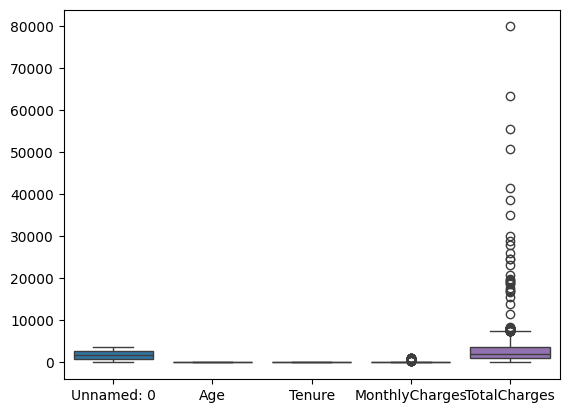

In [370]:
sns.boxplot(data)

In [314]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3749 entries, 0 to 3748
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        3749 non-null   int64  
 1   CustomerID        3749 non-null   object 
 2   Age               3562 non-null   float64
 3   Gender            3749 non-null   object 
 4   Tenure            3749 non-null   int64  
 5   Service_Internet  3028 non-null   object 
 6   Service_Phone     3749 non-null   object 
 7   Service_TV        3749 non-null   object 
 8   Contract          3749 non-null   object 
 9   PaymentMethod     3562 non-null   object 
 10  MonthlyCharges    3749 non-null   float64
 11  TotalCharges      3749 non-null   float64
 12  StreamingMovies   3749 non-null   object 
 13  StreamingMusic    3749 non-null   object 
 14  OnlineSecurity    3749 non-null   object 
 15  TechSupport       3749 non-null   object 
 16  Churn             3749 non-null   object 


Gender,Service_Internet,Service_Phone,Service_TV,Contract,PaymentMethod,StreamingMovies,StreamingMusic,OnlineSecurity,TechSupport,Churn

age, service_internet,payment method contains null values

In [315]:
data.describe()

,Unnamed: 0,Age,Tenure,MonthlyCharges,TotalCharges
count,3749.000000,3562.000000,3749.000000,3749.000000,3749.000000
mean,1874.000000,43.655531,36.264070,75.844318,2718.968266
std,1082.387408,14.914474,20.505528,73.062971,3211.879149
min,0.000000,18.000000,1.000000,20.000000,13.190000
25%,937.000000,31.000000,19.000000,44.570000,1076.240000
50%,1874.000000,44.000000,36.000000,69.590000,2132.260000
75%,2811.000000,56.000000,54.000000,95.540000,3619.710000
max,3748.000000,69.000000,71.000000,1179.300000,79951.800000


In [ ]:
#data.drop(columns=['StreamingMovies','StreamingMusic','OnlineSecurity','TechSupport','Service_TV','Service_Phone','Churn'],inplace= True)
#data.drop(columns=['Churn'],inplace= True)
#data.drop(columns=['Gender'],inplace= True)
#data.drop(columns=['CustomerID','Unnamed: 0'],inplace=True)

visulaisation

<Axes: ylabel='TotalCharges'>

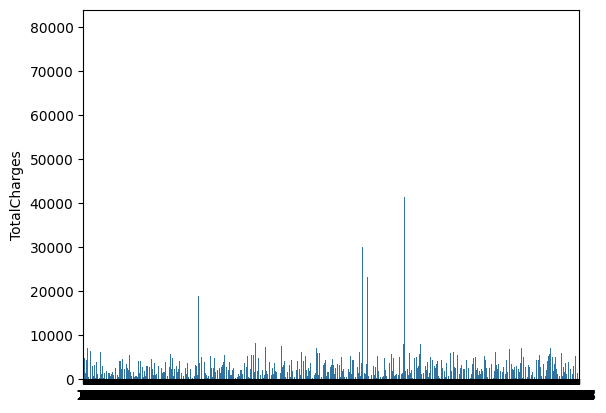

In [18]:
#sns.barplot(data['Age'],)
sns.barplot(data['TotalCharges'],)
#sns.histplot(data['MonthlyCharges'],kde=True)

# tenure, age, are quite static
# monthly charges,  total charges seem to be skewed

# section 2
cleaning and preprocessing

## null values imputation 
1. simple function or (random)
2. sklearn imputer


In [327]:
data.isnull().sum()

Age                 187
Tenure                0
Service_Internet    721
Service_Phone         0
Service_TV            0
Contract              0
PaymentMethod       187
MonthlyCharges        0
TotalCharges          0
StreamingMovies       0
StreamingMusic        0
OnlineSecurity        0
TechSupport           0
Churn                 0
dtype: int64

In [328]:
def fill_na_random(df, str1, str2):
    return df.apply(lambda x: np.random.choice([str1, str2]) if pd.isna(x) else x)
data['Service_Internet'] = fill_na_random(data['Service_Internet'], 'Fiber optic','DSL')

In [329]:
def fill_na_random(df, str1, str2,str3, str4):
    return df.apply(lambda x: np.random.choice([str1, str2, str3,str4]) if pd.isna(x) else x)
data['PaymentMethod'] = fill_na_random(data['PaymentMethod'], 'Electronic check','Bank transfer','Mailed check','Credit card')

## detetcting outilers

In [282]:
# treating monthly charges and total charges

In [283]:
# Detecting outliers using the IQR method
Q1 = data['MonthlyCharges'].quantile(0.25)
Q3 = data['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Capping outliers
data['MonthlyCharges'] = np.where(data['MonthlyCharges'] > upper_bound, upper_bound,
                                       np.where(data['MonthlyCharges'] < lower_bound, lower_bound, data['MonthlyCharges']))

Q1 = data['TotalCharges'].quantile(0.25)
Q3 = data['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Capping outliers
data['TotalCharges'] = np.where(data['TotalCharges'] > upper_bound, upper_bound,
                                       np.where(data['TotalCharges'] < lower_bound, lower_bound, data['TotalCharges']))



# categorical data encoding and merge

In [ ]:
#run once
le.fit(['Yes','No']) # yess =1 , no= 0
data['Service_TV']= le.transform(data['Service_TV'])
data['Service_Phone']= le.transform(data['Service_Phone'])
data['StreamingMovies']= le.transform(data['StreamingMovies'])
data['StreamingMusic']= le.transform(data['StreamingMusic'])
data['OnlineSecurity']= le.transform(data['OnlineSecurity'])
data['TechSupport']= le.transform(data['TechSupport'])
data['Churn']= le.transform(data['Churn'])

In [352]:
#data = data.join(data_services)
data.head()

,Age,Tenure,Service_Internet,Service_Phone,Service_TV,Contract,PaymentMethod,MonthlyCharges,TotalCharges,StreamingMovies,StreamingMusic,OnlineSecurity,TechSupport,Churn
0,56.0,13,0,1,0,One year,Mailed check,71.88,931.49,0,0,1,0,0
1,69.0,13,0,0,1,Two year,Mailed check,110.99,1448.46,1,1,0,0,0
2,46.0,60,1,0,1,Month-to-month,Mailed check,116.74,6997.73,1,1,0,0,0
3,32.0,57,1,1,1,Month-to-month,Bank transfer,78.16,4452.13,0,1,0,1,0
4,60.0,52,1,1,1,Two year,Electronic check,30.33,1569.73,1,0,1,1,0


In [336]:
#run once
le.fit(['DSL','Fiber optic'])
data['Service_Internet']= le.transform(data['Service_Internet'])

<Axes: >

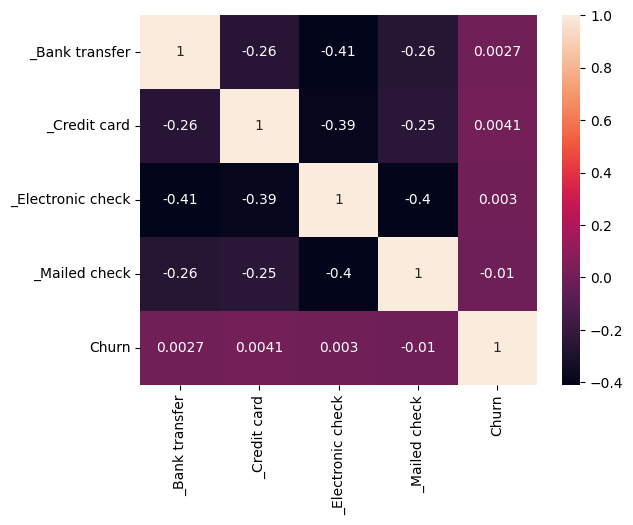

In [365]:
# encode payment method
pay_method_df = pd.get_dummies(data['PaymentMethod'],prefix="")
pay_method_df.head()
pay_method_df = pay_method_df.join(data['Churn'])
corr_mat3 = pay_method_df.corr()
sns.heatmap(corr_mat3,annot=True)

<Axes: >

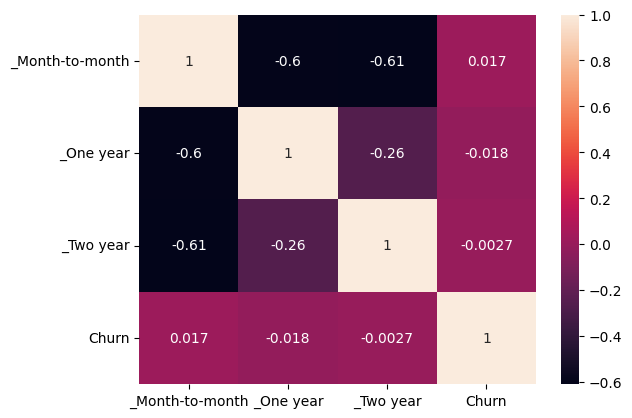

In [366]:
# encode contract
contract_df = pd.get_dummies(data['Contract'],prefix="")
contract_df.head()
contract_df = contract_df.join(data['Churn'])
corr_mat3 = contract_df.corr()
sns.heatmap(corr_mat3,annot=True)

In [ ]:
# balanced data


yes = data[data['Churn'] == 1].head(250)
no = data[data['Churn'] == 0].head(250)


# Concatenate 
final_data = pd.concat([yes,no])

# Shuffle 
final_data = final_data.sample(frac=1).reset_index(drop=True)
y = final_data['Churn']
final_data.drop(columns = 'Churn',inplace = True)
X_train,x_test,y_train,y_test = train_test_split(final_data,y,test_size= 0.20,random_state =42)

In [ ]:
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN':KNeighborsClassifier(n_neighbors=3),
    'Poly_SVC': SVC(kernel="poly", degree=3, coef0=1, C=5),
    'Bagging': BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,max_samples=50, bootstrap=True, n_jobs=-1),


}

# Iterate over classifiers and perform cross-validation
for clf_name, clf in classifiers.items():
    pipeline = Pipeline([
        ('classifier', clf)
    ])
    # Perform cross-validation
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    print(f'{clf_name} Cross-Validation Accuracy: {scores.mean()}')

    # Fit the classifier to the training data
    pipeline.fit(X_train, y_train)

    # Predict on the test set
    y_train_pred = pipeline.predict(x_train)
    y_pred = pipeline.predict(X_test)

    # Evaluate the classifier
    accuracy_train = accuracy_score(y_train, y_train_pred)
    print(f'{clf_name} Train Accuracy: {accuracy_train}\n')
    accuracy_test = accuracy_score(y_test, y_pred)
    print(f'{clf_name} Test Accuracy: {accuracy_test}\n')

    precision_train = precision_score(y_train, y_train_pred)
    print(f'{clf_name} Train precision: {precision_train}\n')
    precision_test = precision_score(y_test, y_pred)
    print(f'{clf_name} Test precision: {precision_test}\n')

    recall_train = recall_score(y_train, y_train_pred)
    print(f'{clf_name} Train recall: {recall_train}\n')
    recall_test = recall_score(y_test, y_pred)
    print(f'{clf_name} Test recall: {recall_test}\n')

    F1_train = F1_score(y_train, y_train_pred)
    print(f'{clf_name} Train F1: {F1_train}\n')
    F1_test = F1_score(y_test, y_pred)
    print(f'{clf_name} Test F1: {F1_test}\n')

    cm_train = confusion_matrix(y_train,y_train_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_train)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'{clf_name}')
    plt.show()

    cm_test = confusion_matrix(y_test,y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'{clf_name}')
    plt.show()


In [ ]:
param_grid = {
    'sgd':{
    'sgd__loss': ['hinge', 'log_loss', 'modified_huber'],
    'sgd__penalty': ['l2', 'l1', 'elasticnet'],
    'sgd__alpha': [0.0001, 0.001, 0.01],
    'sgd__learning_rate': ['constant', 'optimal', 'invscaling'],
    'sgd__eta0': [0.01, 0.1, 1],
    'sgd__max_iter': [1000, 2000, 3000]},

    'random forest':{
    'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [None, 10, 20],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf': [1, 2, 4]

    }}
classifiers = {'sgd':SGDClassifier(),
               'random forest':RandomForestClassifier(),}

for clf_name, clf in classifiers.items():
    print(f"Tuning {clf_name}...")
    pipeline = Pipeline([
        ('clf', clf)
    ])
    grid_search = GridSearchCV(pipeline, param_grid[clf_name], cv=5, n_jobs=-1, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    #evaluate on training
y_train_pred = best_model.predict(X_train)
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)
print("Train set performance:")
print(classification_report(y_train, y_train_pred))
cm = confusion_matrix(y_train,y_train_pred)
# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Make predictionson test
y_pred = best_model.predict(x_test)
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)
print("Test set performance:")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test,y_pred)
# Display the confusion matrixdisp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()




